# 03 Visualizations Notebook
This notebook connects to the database, executes specific SQL queries, and generates charts using Matplotlib and Seaborn. Generated figures are saved to `outputs/figures/`.

In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.database import get_db_engine
from src.config import SQL_DIR, FIGURES_DIR
from src.utils import ensure_dir

engine = get_db_engine()
ensure_dir(FIGURES_DIR)

In [2]:
def run_query(filename):
    sql_file_path = os.path.join(SQL_DIR, filename)
    with open(sql_file_path, 'r') as f:
        query = f.read()
    return pd.read_sql(query, engine)

### Visualization 1: Top 10 States by Sales


C:\Users\piyus\AppData\Local\Temp\ipykernel_2912\707496854.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_sales", y="state", data=df_state_sales, palette="viridis")


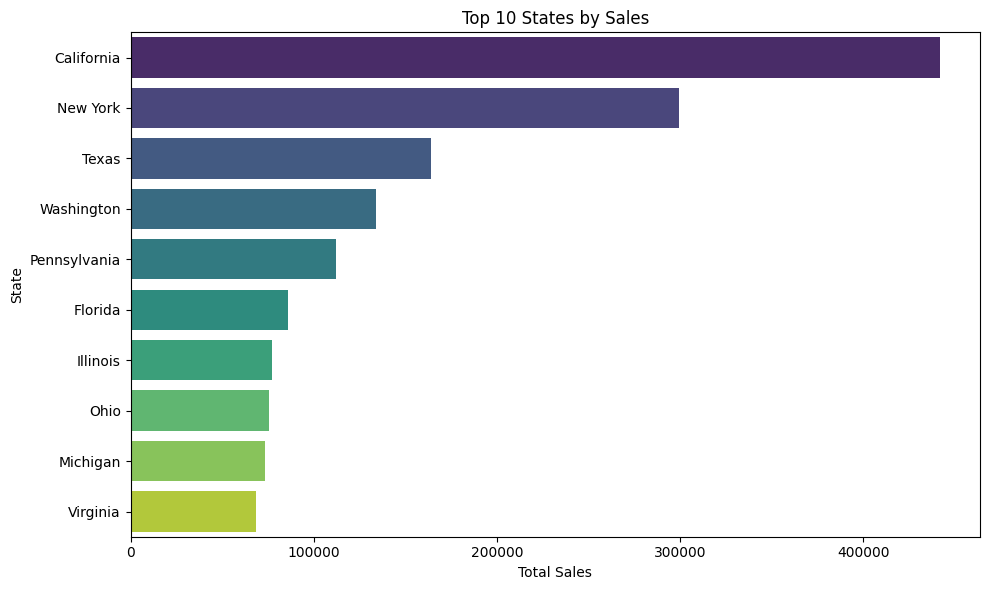

In [3]:
df_state_sales = run_query("state_sales.sql")
plt.figure(figsize=(10, 6))
sns.barplot(x="total_sales", y="state", data=df_state_sales, palette="viridis")
plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "top_states_by_sales.png"))
plt.show()

### Visualization 2: Average Profit by Category


C:\Users\piyus\AppData\Local\Temp\ipykernel_2912\27962203.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="category", y="avg_profit", data=df_avg_profit, palette="Blues_r")


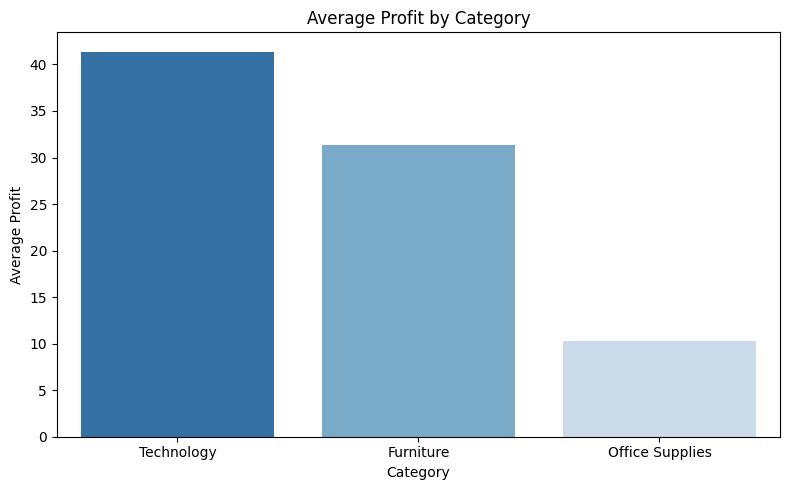

In [4]:
df_avg_profit = run_query("category_avg_profit.sql")
plt.figure(figsize=(8, 5))
sns.barplot(x="category", y="avg_profit", data=df_avg_profit, palette="Blues_r")
plt.title("Average Profit by Category")
plt.xlabel("Category")
plt.ylabel("Average Profit")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "average_profit_by_category.png"))
plt.show()

### Visualization 3: Top 10 Cities by Profit


C:\Users\piyus\AppData\Local\Temp\ipykernel_2912\1000473202.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_profit", y="city", data=df_city_profit, palette="magma")


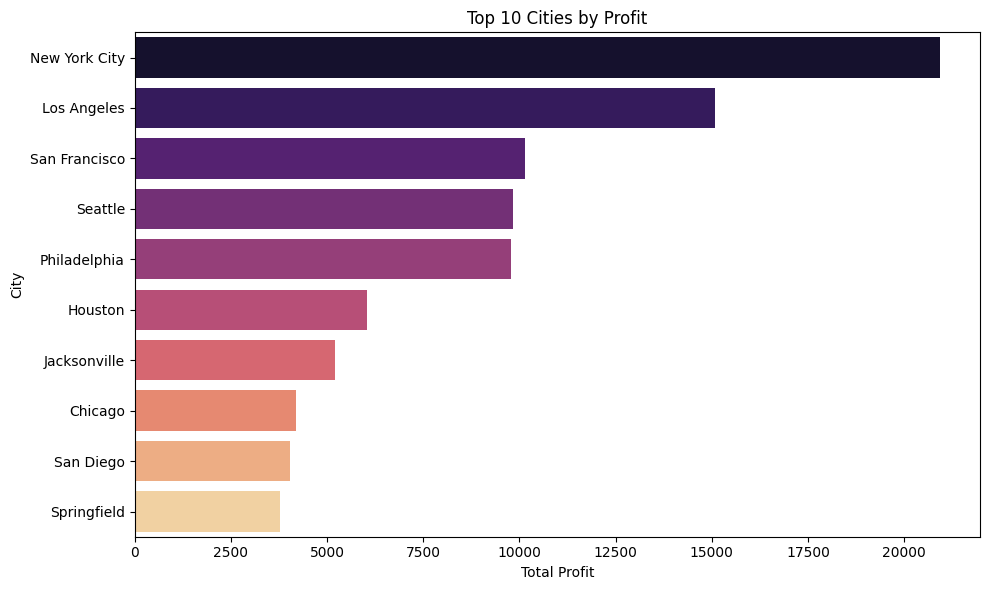

In [5]:
df_city_profit = run_query("city_profit.sql")
plt.figure(figsize=(10, 6))
sns.barplot(x="total_profit", y="city", data=df_city_profit, palette="magma")
plt.title("Top 10 Cities by Profit")
plt.xlabel("Total Profit")
plt.ylabel("City")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "top_cities_by_profit.png"))
plt.show()

### Visualization 4: Top 5 States by Profit


C:\Users\piyus\AppData\Local\Temp\ipykernel_2912\4247516783.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_profit", y="state", data=df_state_profit, palette="crest")


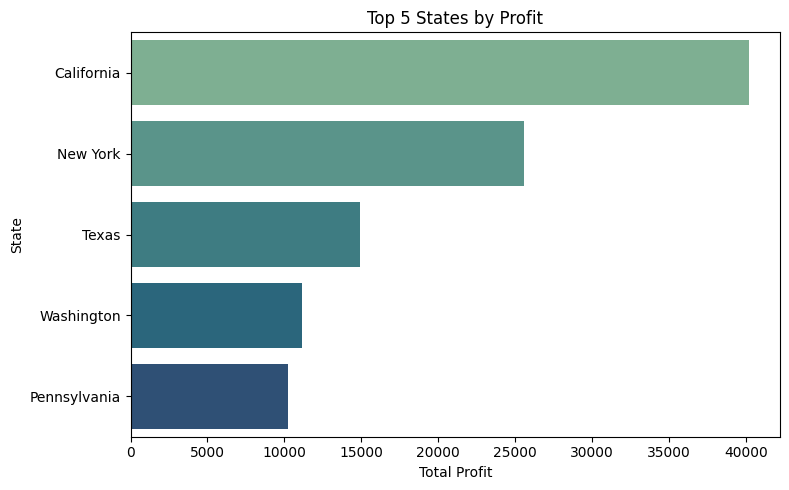

In [6]:
df_state_profit = run_query("state_profit.sql")
plt.figure(figsize=(8, 5))
sns.barplot(x="total_profit", y="state", data=df_state_profit, palette="crest")
plt.title("Top 5 States by Profit")
plt.xlabel("Total Profit")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "top_states_by_profit.png"))
plt.show()

### Visualization 5: Average Discount and Profit by Category


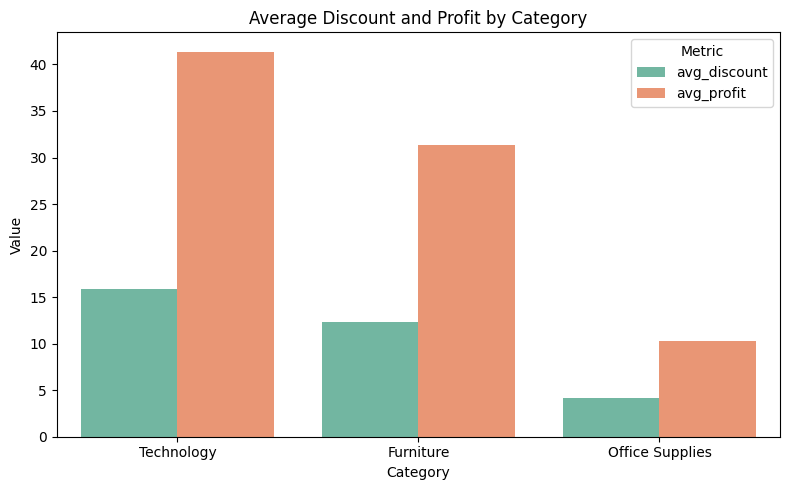

In [7]:
df_discount = run_query("category_discount.sql")
df_melted = df_discount.melt(id_vars=["category"], value_vars=["avg_discount", "avg_profit"], 
                             var_name="Metric", value_name="Value")
plt.figure(figsize=(8, 5))
sns.barplot(x="category", y="Value", hue="Metric", data=df_melted, palette="Set2")
plt.title("Average Discount and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Value")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "avg_discount_profit_by_category.png"))
plt.show()